# Comparative Taxonomy of Market Regimes
### Machine Learning versus Hidden Markov Models in US Tactical Sector Allocation

---

**Pipeline overview:**

| Step | Description |
|------|-------------|
| 1 | Data Loading (sector ETFs, VIX, RF, macro spreads) |
| 2 | Feature Engineering (log-returns, excess returns, feature matrices) |
| 3 | Regime Identification (VIX rules · HMM · GMM+RF) |
| 4 | Regime-Conditional CAPM Beta Analysis |
| 5 | Walk-Forward Backtest |
| 6 | Performance Metrics |
| 7 | Visualization (11 publication-quality figures) |

All outputs are also saved to `market_regimes/results/`.

## ⚙️ Environment Setup

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ── Ensure the market_regimes package is importable ──────────────────────────
MODULE_DIR = os.path.join(os.getcwd(), "market_regimes")
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

# ── Inline matplotlib ────────────────────────────────────────────────────────
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 120

print(f"Python : {sys.version.split()[0]}")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print(f"Module dir: {MODULE_DIR}")

Python : 3.13.9
NumPy  : 2.3.5
Pandas : 2.3.3
Module dir: /Users/alper/Documents/antigravity/peaceful-brahmagupta/market_regimes


In [2]:
import config as CFG

from data.loader import load_all_data
from data.features import (
    compute_log_returns, compute_excess_returns,
    build_hmm_features, build_gmm_features, build_rf_features,
)
from regimes.vix_classifier import classify_vix_regimes, regime_statistics
from regimes.hmm_model      import HMMRegimeModel, fit_hmm_walkforward
from regimes.ml_pipeline    import fit_ml_walkforward
from portfolio.ledoit_wolf  import robust_covariance
from portfolio.backtest     import run_backtest, cumulative_wealth, weight_history, STRATEGY_NAMES
from capm.beta_analysis     import estimate_capm_betas, beta_summary_table
from performance.metrics    import sharpe_ratio, full_performance_table

print("✓ All modules imported successfully.")

✓ All modules imported successfully.


---
## Step 1 — Data Loading

Downloads (or loads from cache) adjusted close prices for 9 sector ETFs + SPY, the CBOE VIX index, the 13-week T-Bill risk-free rate, the TED spread, and the 10Y-2Y term spread.

In [3]:
os.makedirs(os.path.join(MODULE_DIR, CFG.RESULTS_DIR), exist_ok=True)

data_raw = load_all_data(
    start=CFG.START_DATE,
    end=CFG.END_DATE,
    sector_etfs=CFG.SECTOR_ETFS,
    benchmark=CFG.BENCHMARK,
    cache_path=os.path.join(MODULE_DIR, CFG.DATA_CACHE),
    force_reload=False,
)

prices = data_raw["prices"]
vix    = data_raw["vix"]
rf     = data_raw["rf"]
ted    = data_raw["ted"]
term   = data_raw["term"]

print(f"\nPrices shape   : {prices.shape}")
print(f"Date range     : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Tickers        : {prices.columns.tolist()}")

Loading cached data from /Users/alper/Documents/antigravity/peaceful-brahmagupta/market_regimes/results/data_cache.pkl …

Prices shape   : (5534, 10)
Date range     : 2004-01-02 → 2025-12-30
Tickers        : ['SPY', 'XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']


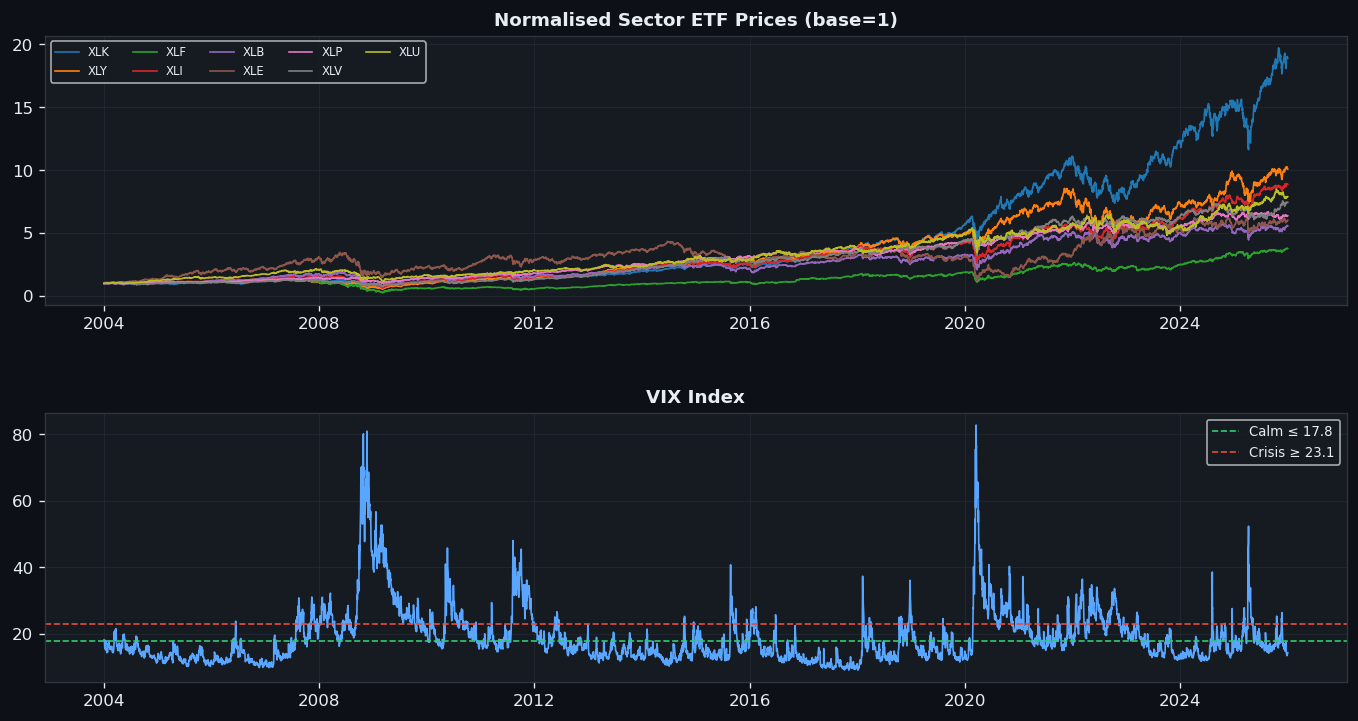

In [4]:
# ── Quick sanity plot: normalised price history ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"hspace": 0.4})
fig.patch.set_facecolor("#0D1117")

ax = axes[0]
ax.set_facecolor("#161B22")
for col in CFG.SECTOR_ETFS:
    if col in prices.columns:
        norm = prices[col] / prices[col].iloc[0]
        ax.plot(prices.index, norm, lw=1.0, label=col)
ax.set_title("Normalised Sector ETF Prices (base=1)", color="#E6EDF3", fontsize=11, fontweight="bold")
ax.tick_params(colors="#E6EDF3")
ax.set_facecolor("#161B22")
for sp in ax.spines.values(): sp.set_color("#30363D")
ax.legend(ncol=5, fontsize=7, facecolor="#161B22", labelcolor="#E6EDF3")
ax.grid(color="#30363D", alpha=0.5, lw=0.5)

ax2 = axes[1]
ax2.set_facecolor("#161B22")
ax2.plot(vix.index, vix.values, color="#58A6FF", lw=1.0)
ax2.axhline(20,          color="#2ECC71", ls="--", lw=1.0, label=f"Calm ≤ {20}")
ax2.axhline(30,  color="#E74C3C", ls="--", lw=1.0, label=f"Crisis ≥ {30}")
ax2.set_title("VIX Index", color="#E6EDF3", fontsize=11, fontweight="bold")
ax2.tick_params(colors="#E6EDF3")
for sp in ax2.spines.values(): sp.set_color("#30363D")
ax2.legend(fontsize=8, facecolor="#161B22", labelcolor="#E6EDF3")
ax2.grid(color="#30363D", alpha=0.5, lw=0.5)

plt.show()

---
## Step 2 — Feature Engineering

Computes log-returns, excess returns over the risk-free rate, and three separate feature matrices tailored to each regime-identification method.

In [5]:
log_ret_all = compute_log_returns(prices)

sector_cols     = [c for c in CFG.SECTOR_ETFS if c in log_ret_all.columns]
spy_col         = CFG.BENCHMARK
log_ret_sectors = log_ret_all[sector_cols]
log_ret_spy     = log_ret_all[spy_col]

excess_sectors  = compute_excess_returns(log_ret_sectors, rf)
excess_spy      = compute_excess_returns(log_ret_spy.to_frame(), rf).squeeze()

rf_features             = build_rf_features(vix, ted, term, log_ret_sectors, lags=CFG.RF_LAG_DAYS)
hmm_feats, hmm_idx      = build_hmm_features(log_ret_sectors, vix)
gmm_feats, gmm_idx      = build_gmm_features(log_ret_sectors, vix)
rf_feature_names        = rf_features.columns.tolist()

print(f"Sector log-returns  : {log_ret_sectors.shape}")
print(f"Excess returns range: {excess_sectors.index[0].date()} → {excess_sectors.index[-1].date()}")
print(f"HMM feature matrix  : {hmm_feats.shape}")
print(f"RF  feature matrix  : {rf_features.shape}  ({len(rf_feature_names)} features)")

Sector log-returns  : (5533, 9)
Excess returns range: 2004-01-05 → 2025-12-30
HMM feature matrix  : (5533, 10)
RF  feature matrix  : (5528, 40)  (40 features)


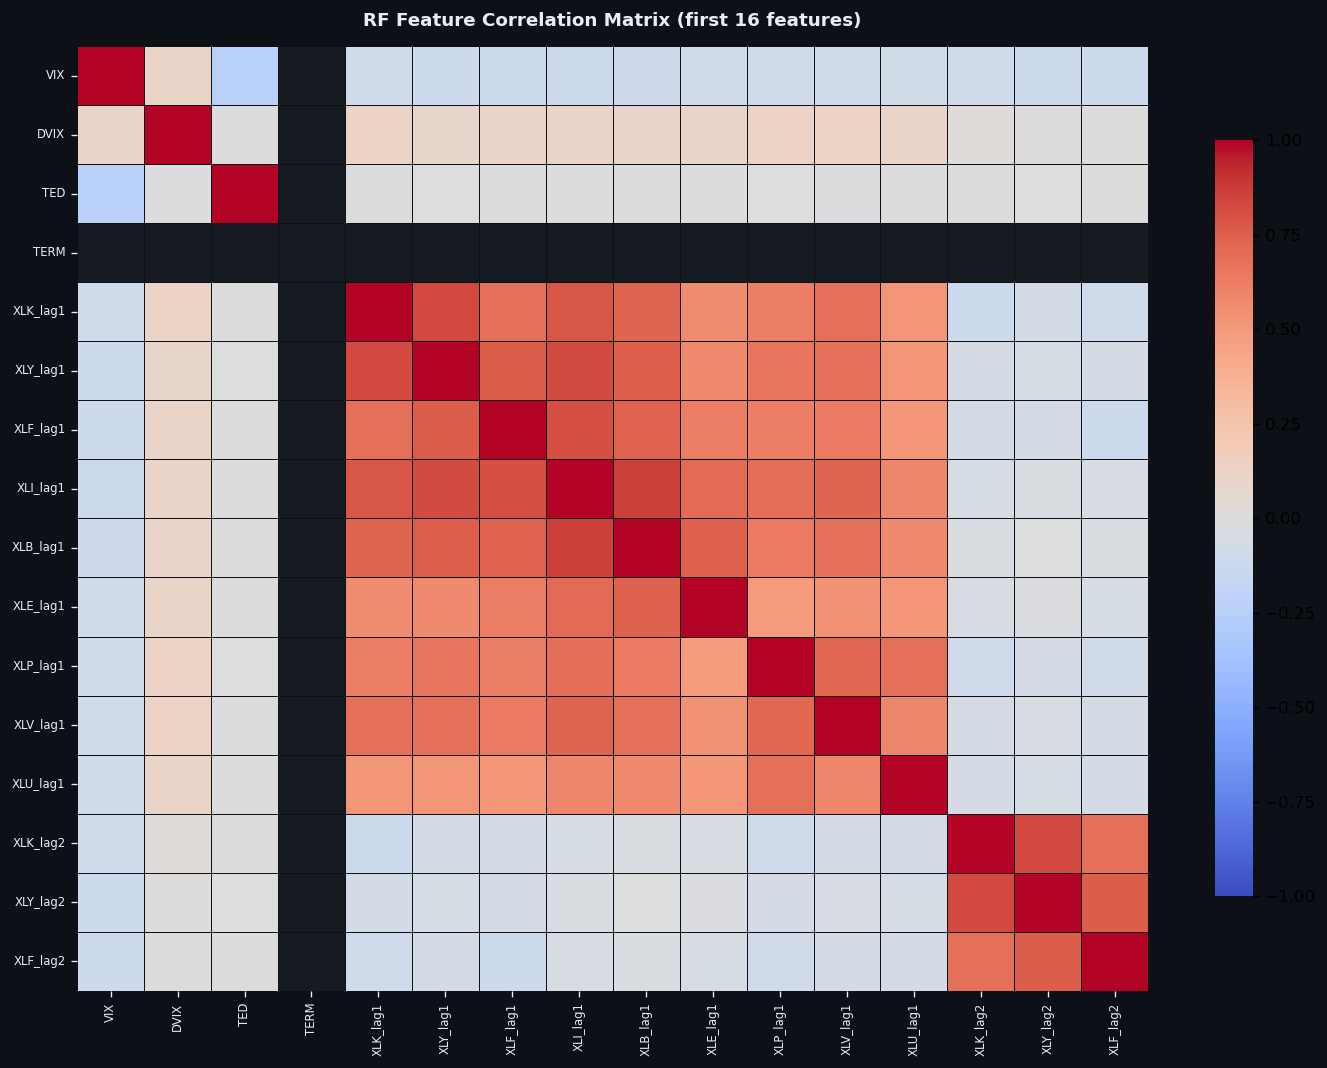

In [6]:
# ── Correlation heatmap of RF features ────────────────────────────────────────
import seaborn as sns

sample_features = rf_features.iloc[:, :16]   # first 16 for readability
corr = sample_features.corr()

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#161B22")
sns.heatmap(
    corr, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="#0D1117",
    annot=False,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("RF Feature Correlation Matrix (first 16 features)", color="#E6EDF3",
             fontsize=11, fontweight="bold", pad=12)
ax.tick_params(colors="#E6EDF3", labelsize=7)
plt.tight_layout()
plt.show()

---
## Step 3 — Regime Identification

Three complementary classifiers assign each trading day to one of three regimes: **Calm (0)**, **Transitional (1)**, or **Crisis (2)**.

| Method | Description |
|--------|-------------|
| **VIX Rules** | Hard thresholds on VIX level (33rd / 67th percentile) |
| **HMM** | 3-state Hidden Markov Model, walk-forward expanding window |
| **GMM + RF** | Gaussian Mixture Model regime labels fed as targets to a Random Forest regressor |

In [7]:
# ── 3a. VIX rule-based regimes ────────────────────────────────────────────────
vix_regimes = classify_vix_regimes(
    vix,
    calm_threshold=20,
    transitional_threshold=30,
)
reg_stats = regime_statistics(vix, vix_regimes, log_ret_sectors)

print("VIX Regime Statistics:")
display(reg_stats.round(4))

reg_stats.to_csv(os.path.join(MODULE_DIR, CFG.RESULTS_DIR, "regime_stats.csv"))
print("\n✓ Saved regime_stats.csv")

VIX Regime Statistics:


,Days,Pct_Days,Mean_VIX,Std_VIX,Mean_EqWt_Ret,Std_EqWt_Ret
Regime,,,,,,
Calm,3210,58.0051,14.0245,2.0570,0.3076,0.0950
Transitional,1177,21.2685,20.1577,1.5407,0.0250,0.1484
Crisis,1147,20.7264,31.6323,10.1828,-0.4423,0.3310



✓ Saved regime_stats.csv


In [8]:
# ── 3b. HMM walk-forward ──────────────────────────────────────────────────────
print("Fitting HMM (walk-forward, expanding window) …")
hmm_kwargs = dict(
    n_states=CFG.HMM_N_STATES,
    n_iter=CFG.HMM_N_ITER,
    n_init=CFG.HMM_N_INIT,
    covariance_type=CFG.HMM_COVARIANCE_TYPE,
    random_state=CFG.HMM_RANDOM_STATE,
)
hmm_regimes, hmm_last_model = fit_hmm_walkforward(
    feature_df=hmm_feats,
    min_train_days=CFG.MIN_TRAIN_DAYS,
    refit_freq=CFG.REFIT_FREQ,
    hmm_kwargs=hmm_kwargs,
)
print(f"HMM labels: {len(hmm_regimes)} days  "
      f"[Calm={(hmm_regimes==0).sum()}, "
      f"Trans={(hmm_regimes==1).sum()}, "
      f"Crisis={(hmm_regimes==2).sum()}]")

if hasattr(hmm_last_model, "transition_matrix"):
    print("\nHMM Transition Matrix:")
    display(
        pd.DataFrame(
            hmm_last_model.transition_matrix,
            index=["Calm","Trans","Crisis"],
            columns=["Calm","Trans","Crisis"],
        ).round(3)
    )

Fitting HMM (walk-forward, expanding window) …


Model is not converging.  Current: 16507.745762022198 is not greater than 16507.756967493013. Delta is -0.011205470815184526
Model is not converging.  Current: 16520.732710522574 is not greater than 16520.7407040378. Delta is -0.00799351522437064
Model is not converging.  Current: 16500.943625928863 is not greater than 16500.967397027824. Delta is -0.023771098960423842
Model is not converging.  Current: 16385.55403446051 is not greater than 16385.554590304768. Delta is -0.0005558442571782507
Model is not converging.  Current: 16503.319954396215 is not greater than 16503.36427502598. Delta is -0.04432062976411544
Model is not converging.  Current: 16489.582604964824 is not greater than 16489.69800757176. Delta is -0.11540260693436721
Model is not converging.  Current: 16499.54327257629 is not greater than 16499.60040774436. Delta is -0.05713516807009
Model is not converging.  Current: 16518.65908334526 is not greater than 16518.69889649935. Delta is -0.03981315408964292
Model is not con

HMM labels: 5029 days  [Calm=2302, Trans=2220, Crisis=507]

HMM Transition Matrix:


,Calm,Trans,Crisis
Calm,0.895,0.105,0.000
Trans,0.162,0.807,0.030
Crisis,0.000,0.166,0.834


In [9]:
# ── 3c. ML (GMM + RF) walk-forward ───────────────────────────────────────────
print("Fitting ML pipeline (GMM + RF, walk-forward) …")

next_day_ret = log_ret_sectors.shift(-1).dropna()
ml_kwargs = dict(
    gmm_n_components=CFG.GMM_N_COMPONENTS,
    gmm_n_init=CFG.GMM_N_INIT,
    gmm_covariance_type=CFG.GMM_COVARIANCE_TYPE,
    gmm_random_state=CFG.GMM_RANDOM_STATE,
    rf_n_estimators=CFG.RF_N_ESTIMATORS,
    rf_max_depth=CFG.RF_MAX_DEPTH,
    rf_min_samples=CFG.RF_MIN_SAMPLES,
    rf_random_state=CFG.RF_RANDOM_STATE,
    rf_n_jobs=CFG.RF_N_JOBS,
)
ml_regimes, ml_return_preds, ml_last_pipeline = fit_ml_walkforward(
    gmm_features=gmm_feats,
    rf_features=rf_features,
    log_returns=next_day_ret,
    min_train_days=CFG.MIN_TRAIN_DAYS,
    refit_freq=CFG.REFIT_FREQ,
    ml_kwargs=ml_kwargs,
)
print(f"ML labels:  {len(ml_regimes)} days  "
      f"[Calm={(ml_regimes==0).sum()}, "
      f"Trans={(ml_regimes==1).sum()}, "
      f"Crisis={(ml_regimes==2).sum()}]")
print("\n✓ All three regime classifiers fitted.")

Fitting ML pipeline (GMM + RF, walk-forward) …
ML labels:  5023 days  [Calm=3022, Trans=1612, Crisis=389]

✓ All three regime classifiers fitted.


---
## Step 4 — Regime-Conditional CAPM Beta Analysis

In [10]:
beta_full = estimate_capm_betas(excess_sectors, excess_spy, vix_regimes)
beta_summ = beta_summary_table(beta_full)

print("CAPM Beta Summary (VIX regimes):")
display(beta_summ.round(3))

beta_summ.to_csv(os.path.join(MODULE_DIR, CFG.RESULTS_DIR, "beta_summary.csv"))
print("\n✓ Saved beta_summary.csv")

CAPM Beta Summary (VIX regimes):


,Calm_alpha,Calm_beta,Calm_r2,Transitional_alpha,Transitional_beta,Transitional_r2,Crisis_alpha,Crisis_beta,Crisis_r2
Ticker,,,,,,,,,
XLK,0.011,1.172,0.710,-0.030,1.180,0.805,0.017,1.031,0.886
XLY,0.010,1.052,0.688,0.008,1.121,0.767,-0.056,1.014,0.852
XLF,-0.001,1.033,0.613,-0.003,1.127,0.667,-0.035,1.379,0.742
XLI,-0.012,1.007,0.692,0.003,1.005,0.790,0.008,0.987,0.865
XLB,-0.081,1.094,0.561,0.050,1.035,0.648,-0.000,1.045,0.813
XLE,-0.042,0.995,0.270,0.087,1.013,0.363,0.036,1.201,0.667
XLP,-0.025,0.580,0.362,0.104,0.512,0.434,0.042,0.562,0.691
XLV,-0.004,0.806,0.479,-0.014,0.693,0.584,-0.005,0.687,0.747
XLU,0.034,0.513,0.153,0.070,0.479,0.249,0.087,0.701,0.613



✓ Saved beta_summary.csv


---
## Step 5 — Walk-Forward Backtest

Tests **10 strategies** over the common index window, with monthly rebalancing and 10 bps one-way transaction costs.

| Strategy | Description |
|----------|-------------|
| SPY B&H | Buy-and-hold SPY benchmark |
| EW 1/N | Equal-weight naive diversification |
| Static MVP / TPF | Unconditional minimum-variance / tangency portfolios |
| VIX-MVP / VIX-TPF | Regime-switched using VIX rules |
| HMM-MVP / HMM-TPF | Regime-switched using HMM labels |
| ML-MVP / ML-TPF | Regime-switched using GMM+RF labels |

In [11]:
common_idx = (
    excess_sectors.index
    .intersection(excess_spy.index)
    .intersection(vix_regimes.index)
    .intersection(hmm_regimes.index)
    .intersection(ml_regimes.index)
    .sort_values()
)
print(f"Common backtest window: {common_idx[0].date()} → {common_idx[-1].date()} ({len(common_idx)} days)")

ml_preds_aligned = ml_return_preds.reindex(common_idx).ffill().bfill()
if ml_preds_aligned.empty or ml_preds_aligned.isna().all().all():
    ml_preds_aligned = excess_sectors.reindex(common_idx).rolling(21).mean().fillna(0)

port_returns = run_backtest(
    excess_returns=excess_sectors,
    spy_excess=excess_spy,
    rf_daily=rf,
    vix_regimes=vix_regimes,
    hmm_regimes=hmm_regimes,
    ml_regimes=ml_regimes,
    ml_return_preds=ml_preds_aligned,
    rolling_window=CFG.ROLLING_WINDOW,
    rebalance_freq=CFG.REBALANCE_FREQ,
    cost_bps=CFG.TRANSACTION_COST_BPS,
    crisis_cash=CFG.CRISIS_CASH_FRACTION,
    use_shrinkage=CFG.USE_LEDOIT_WOLF,
)
print(f"\nStrategy return matrix: {port_returns.shape}")

rf_bt = rf.reindex(port_returns.index).ffill().bfill()
wealth = cumulative_wealth(port_returns, rf_bt, initial_wealth=1.0)

print("\nRecording weight history …")
wt_hist = weight_history(
    excess_returns=excess_sectors,
    spy_excess=excess_spy,
    rf_daily=rf,
    vix_regimes=vix_regimes,
    hmm_regimes=hmm_regimes,
    ml_regimes=ml_regimes,
    ml_return_preds=ml_preds_aligned,
    rolling_window=CFG.ROLLING_WINDOW,
    rebalance_freq=CFG.REBALANCE_FREQ,
    crisis_cash=CFG.CRISIS_CASH_FRACTION,
    use_shrinkage=CFG.USE_LEDOIT_WOLF,
)
print("✓ Backtest complete.")

Common backtest window: 2006-01-11 → 2025-12-29 (5023 days)

Strategy return matrix: (4771, 10)

Recording weight history …
✓ Backtest complete.


---
## Step 6 — Performance Metrics

In [12]:
spy_sr = sharpe_ratio(excess_spy.reindex(port_returns.index).ffill())

turnover_dict = {
    "SPY B&H":    0.02,
    "EW 1/N":     0.20,
    "Static MVP": 0.40,
    "Static TPF": 0.60,
    "VIX-MVP":    0.50,
    "VIX-TPF":    0.70,
    "HMM-MVP":    0.55,
    "HMM-TPF":    0.75,
    "ML-MVP":     0.60,
    "ML-TPF":     0.80,
}

perf_table = full_performance_table(
    port_returns=port_returns,
    spy_excess=excess_spy,
    rf_daily=rf,
    turnover_dict=turnover_dict,
)

print("Performance Summary:")
display(perf_table.round(3))

perf_table.to_csv(os.path.join(MODULE_DIR, CFG.RESULTS_DIR, "performance_summary.csv"))
print("\n✓ Saved performance_summary.csv")

Performance Summary:


,Ann.Return (%),Ann.Vol (%),Sharpe,Sortino,Max DD (%),Jensen α (%),Beta,p(α),Calmar,Breakeven (bps)
Strategy,,,,,,,,,,
SPY B&H,7.005,19.789,0.441,0.026,-59.576,0.000,1.000,0.001,0.118,0.000
EW 1/N,5.706,19.094,0.387,0.022,-58.489,-0.842,0.942,0.381,0.098,0.000
Static MVP,5.918,14.488,0.470,0.027,-38.802,1.353,0.624,0.437,0.152,102.300
Static TPF,6.743,19.474,0.433,0.025,-46.790,1.756,0.764,0.534,0.144,0.000
VIX-MVP,5.377,13.524,0.455,0.026,-34.551,1.209,0.566,0.487,0.156,37.360
VIX-TPF,5.810,15.706,0.439,0.025,-39.541,0.988,0.676,0.602,0.147,0.000
HMM-MVP,5.911,14.051,0.479,0.028,-41.129,1.669,0.580,0.371,0.144,96.773
HMM-TPF,3.464,19.656,0.272,0.015,-54.773,-1.412,0.775,0.618,0.063,0.000
ML-MVP,6.288,14.172,0.501,0.030,-38.774,1.962,0.589,0.290,0.162,141.790



✓ Saved performance_summary.csv


---
## Step 7 — Visualization

Generates all 11 publication-quality figures inline and also saves them to `market_regimes/results/`.

> **Note:** The plotting module normally uses the non-interactive `Agg` backend. The cells below patch each figure function to display inline before saving.

In [13]:
# Monkey-patch the module's matplotlib backend so figures render inline
import visualization.plots as vp
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

# Patch _save so it shows AND saves each figure
_original_save = vp._save

def _inline_save(fig, path: str, dpi: int = 150):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.show()                         # display inline first
    fig.savefig(path, dpi=dpi, bbox_inches="tight",
                facecolor=vp.PALETTE["bg"], edgecolor="none")
    plt.close(fig)
    print(f"  💾 Saved: {os.path.basename(path)}")

vp._save = _inline_save
print("✓ Visualization module patched for inline display.")

✓ Visualization module patched for inline display.


In [14]:
RESULTS_ABS = os.path.join(MODULE_DIR, CFG.RESULTS_DIR)

plot_data = {
    "vix":              vix,
    "vix_regimes":      vix_regimes,
    "hmm_regimes":      hmm_regimes,
    "ml_regimes":       ml_regimes,
    "hmm_model":        hmm_last_model,
    "log_returns":      log_ret_sectors,
    "excess_returns":   excess_sectors,
    "spy_excess":       excess_spy,
    "wealth":           wealth,
    "port_returns":     port_returns,
    "rf_daily":         rf,
    "beta_summary":     beta_summ,
    "weight_history":   wt_hist,
    "ml_pipeline":      ml_last_pipeline,
    "rf_feature_names": rf_feature_names,
    "perf_table":       perf_table,
    "spy_sr":           spy_sr,
    "turnover_dict":    turnover_dict,
}

### Figure 1 — VIX Regime Timeline

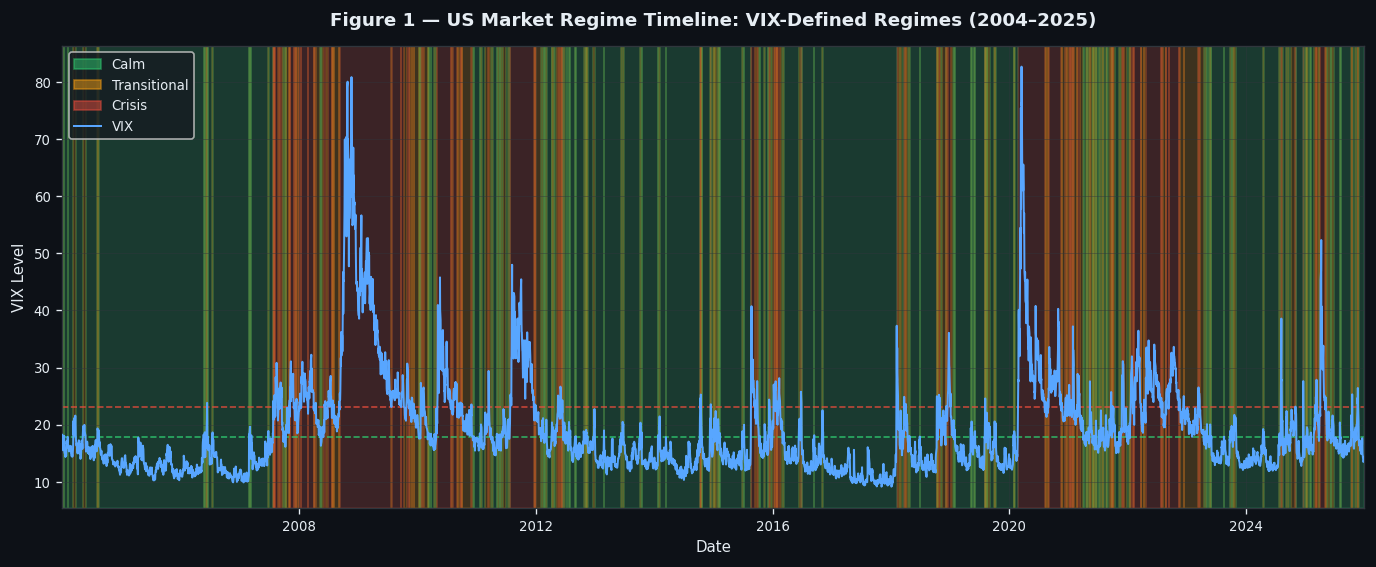

  💾 Saved: 01_regime_timeline.png


In [15]:
vp.plot_regime_timeline(vix, vix_regimes, RESULTS_ABS)

### Figure 2 — Regime Comparison Heatmap (VIX / HMM / ML)

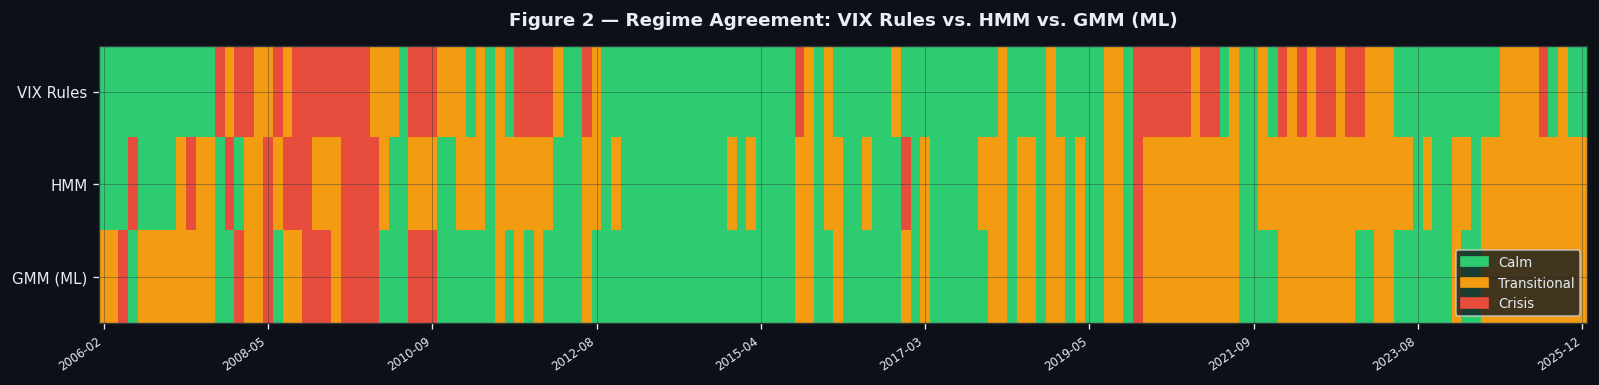

  💾 Saved: 02_regime_comparison_heatmap.png


In [16]:
vp.plot_regime_comparison(vix_regimes, hmm_regimes, ml_regimes, RESULTS_ABS)

### Figure 3 — HMM Transition Probability Matrix

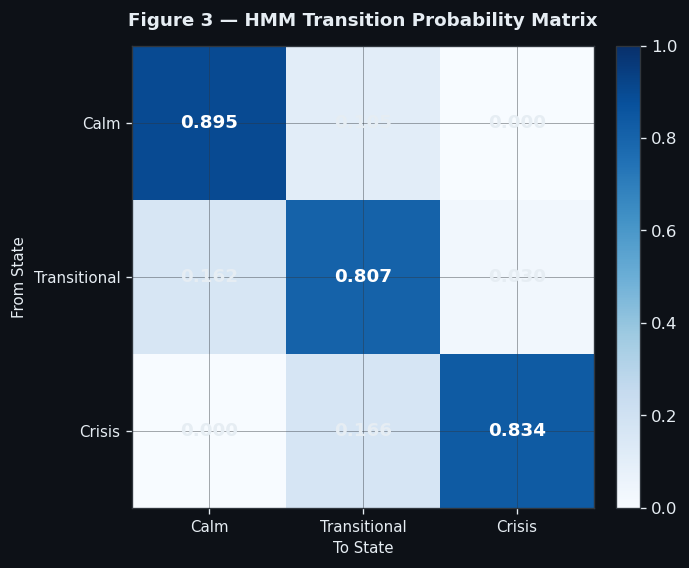

  💾 Saved: 03_transition_matrix.png


In [17]:
if hasattr(hmm_last_model, "transition_matrix"):
    vp.plot_transition_matrix(hmm_last_model.transition_matrix, RESULTS_ABS)
else:
    print("HMM transition matrix not available.")

### Figure 4 — Regime-Conditional Return Distributions

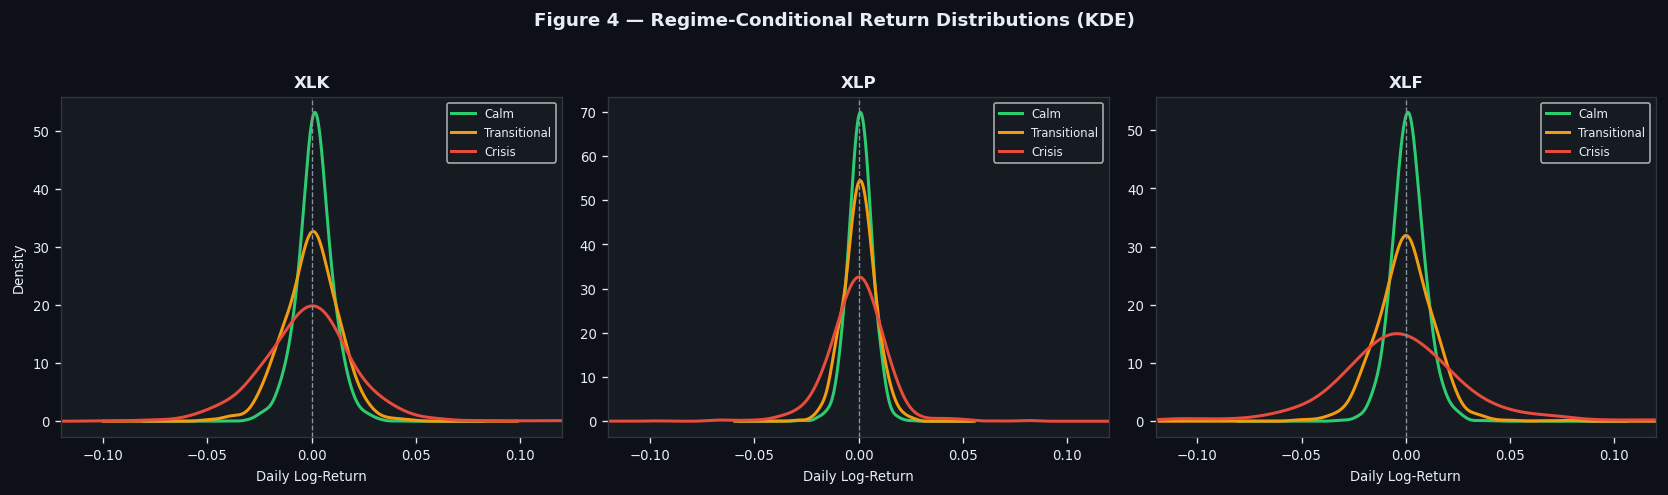

  💾 Saved: 04_return_distributions.png


In [18]:
vp.plot_return_distributions(log_ret_sectors, vix_regimes, RESULTS_ABS)

### Figure 5 — Regime-Conditional CAPM Betas

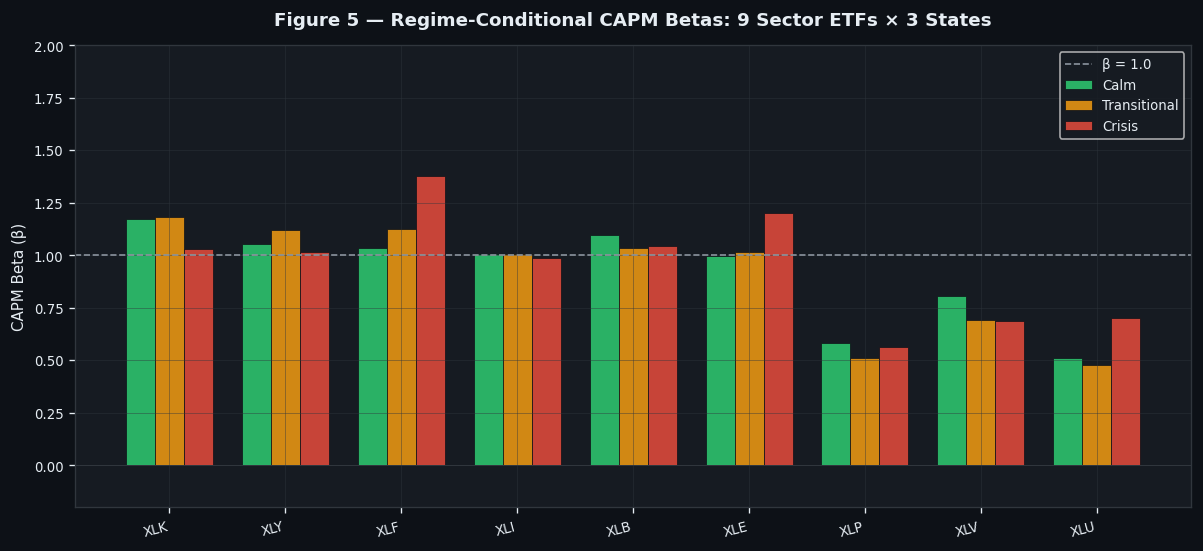

  💾 Saved: 05_capm_betas.png


In [19]:
vp.plot_capm_betas(beta_summ, RESULTS_ABS)

### Figure 6 — Dynamic Portfolio Weights

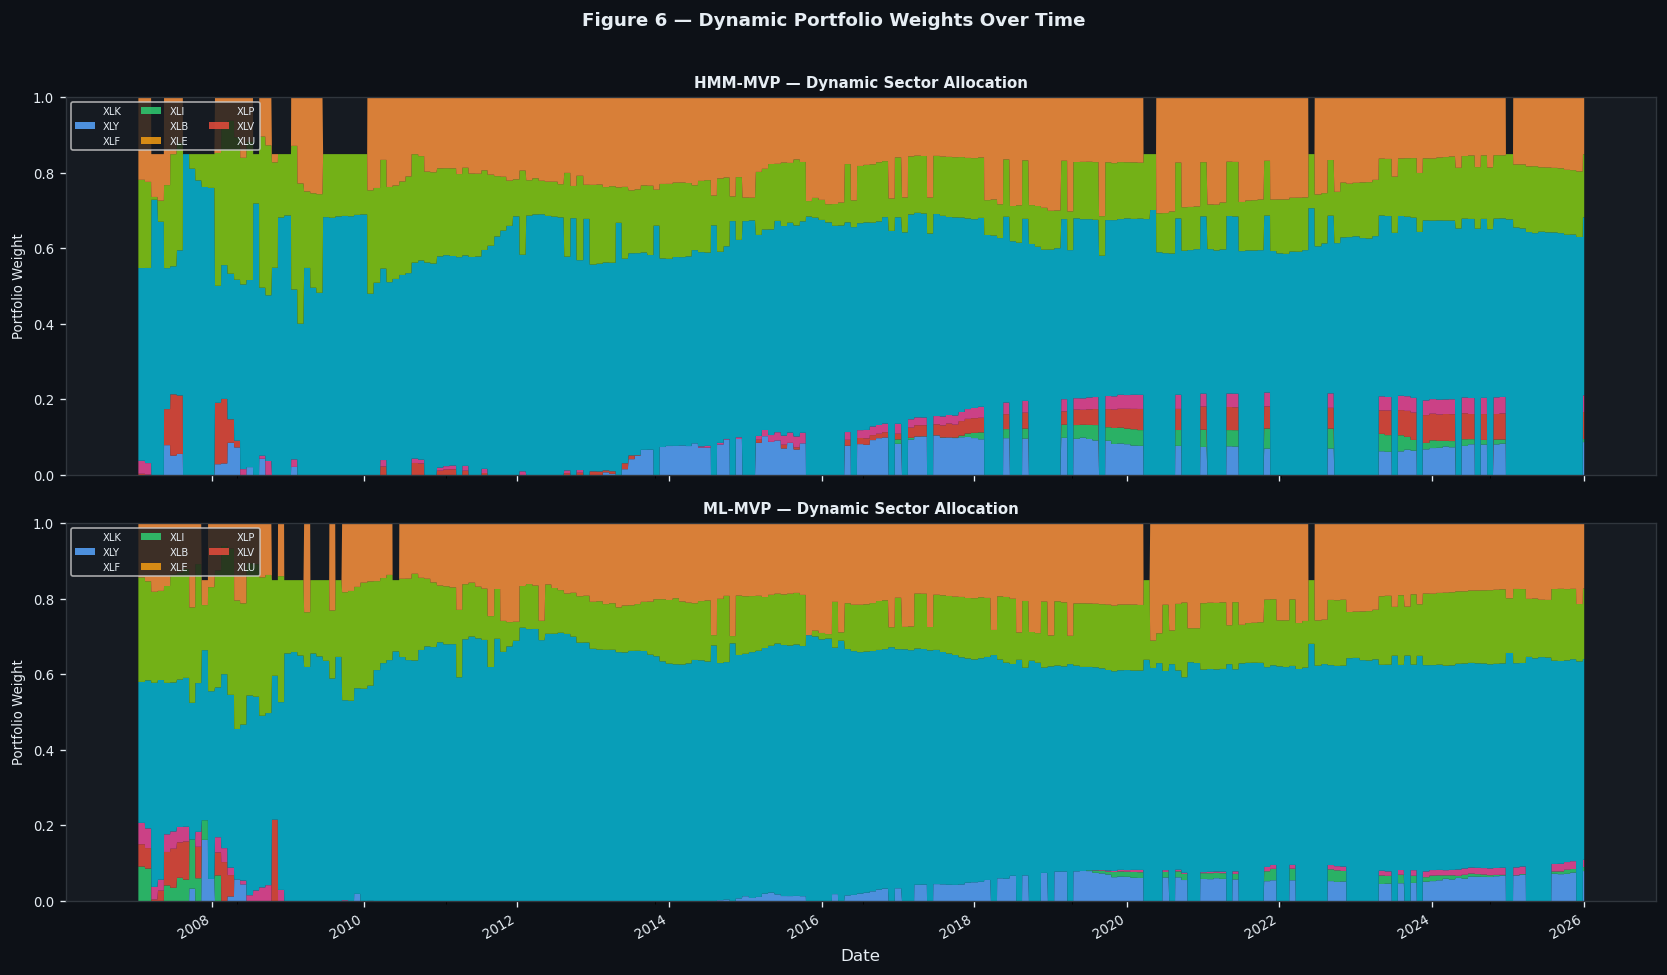

  💾 Saved: 06_portfolio_weights.png


In [20]:
vp.plot_portfolio_weights(wt_hist, RESULTS_ABS)

### Figure 7 — Cumulative Wealth (Log Scale)

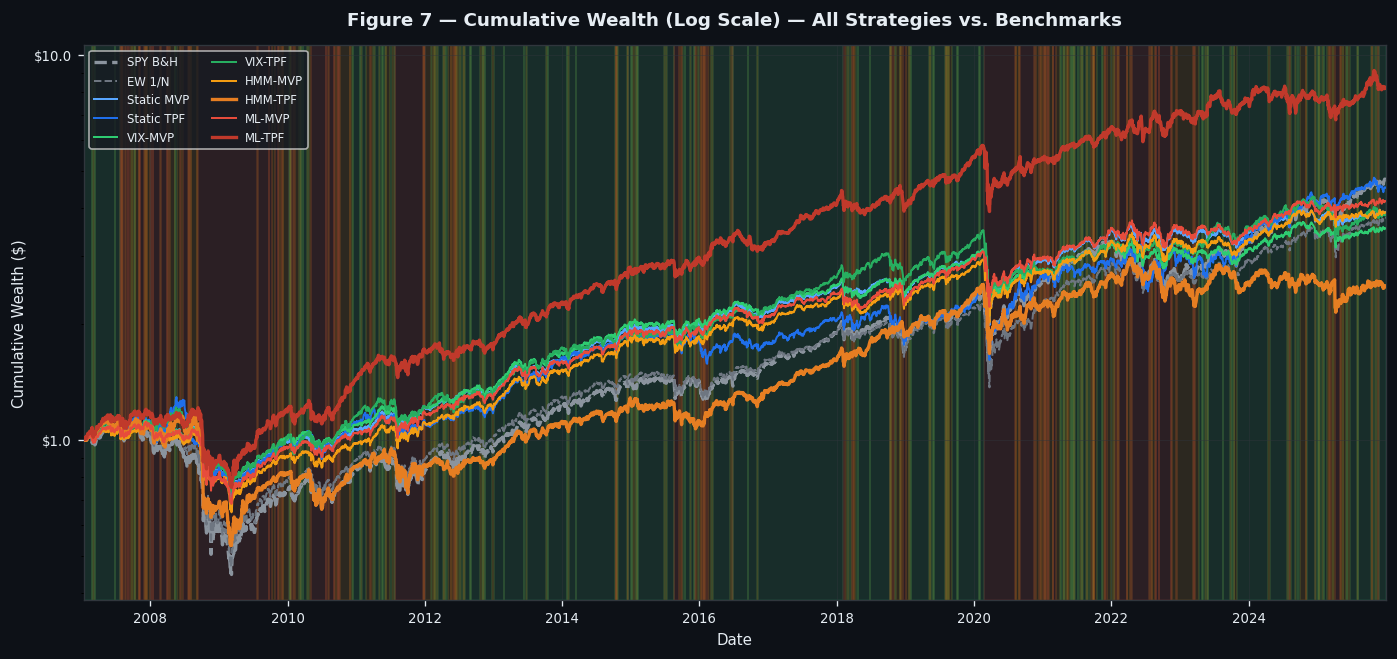

  💾 Saved: 07_cumulative_wealth.png


In [21]:
vp.plot_cumulative_wealth(wealth, vix_regimes, RESULTS_ABS)

### Figure 8 — Performance Summary Table

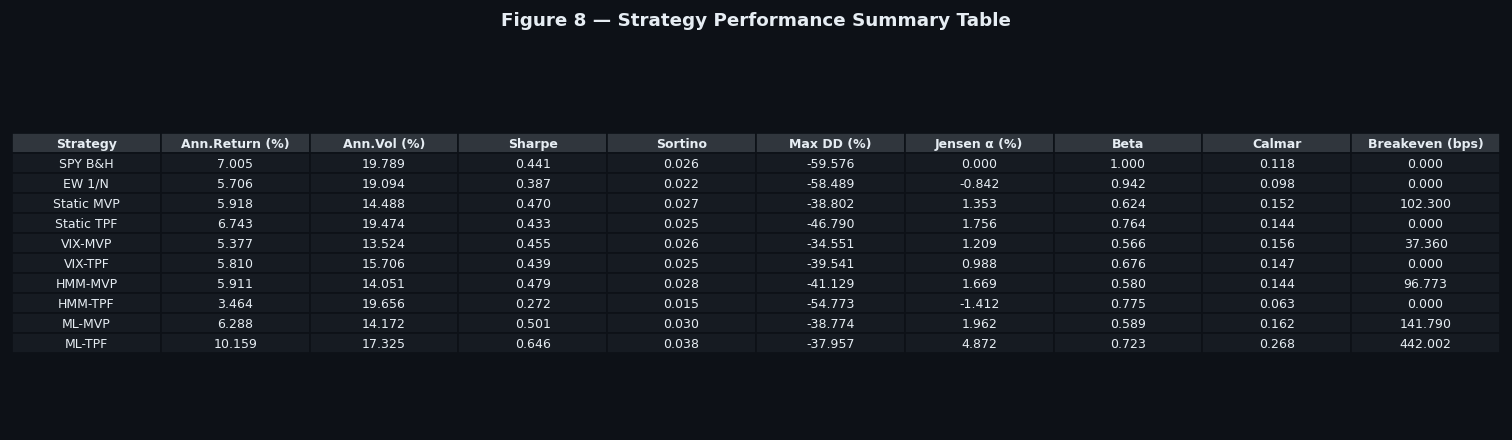

  💾 Saved: 08_performance_table.png


In [22]:
vp.plot_performance_table(perf_table, RESULTS_ABS)

### Figure 9 — Drawdown Profiles

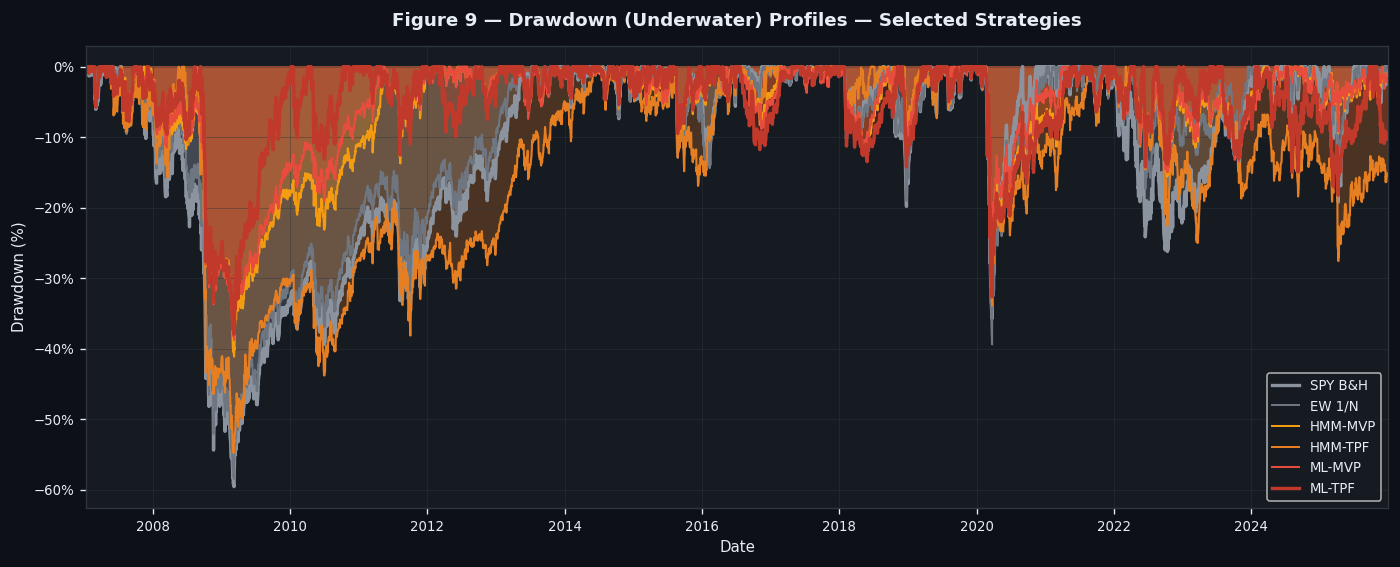

  💾 Saved: 09_drawdown_profiles.png


In [23]:
vp.plot_drawdown_profiles(wealth, RESULTS_ABS)

### Figure 10 — Break-Even Transaction Cost Analysis

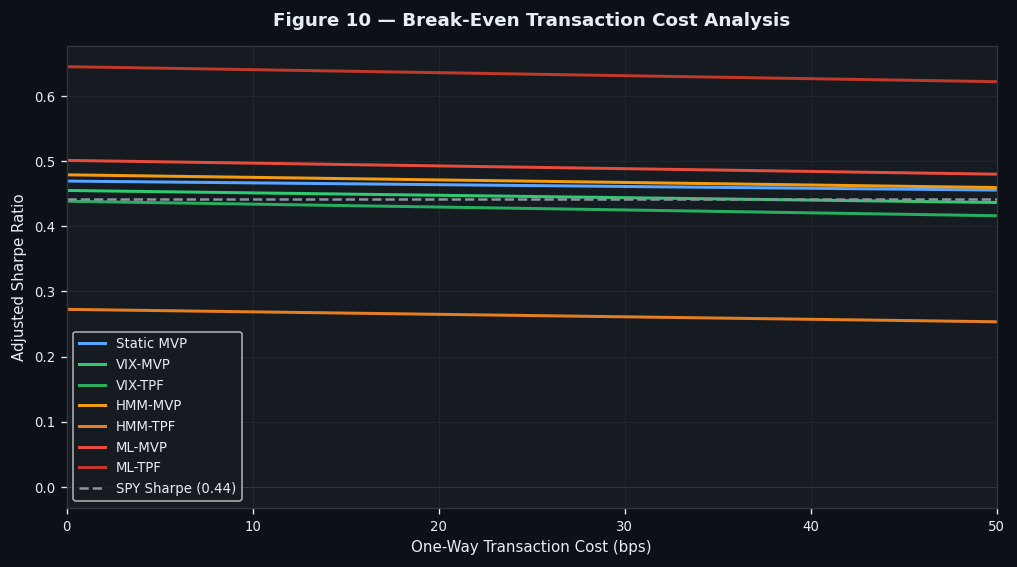

  💾 Saved: 10_breakeven_costs.png


In [24]:
vp.plot_breakeven_costs(
    port_returns, spy_sr, CFG.BREAKEVEN_COST_RANGE, RESULTS_ABS,
    annual_turnover_dict=turnover_dict,
)

### Figure 11 — Random Forest Feature Importances

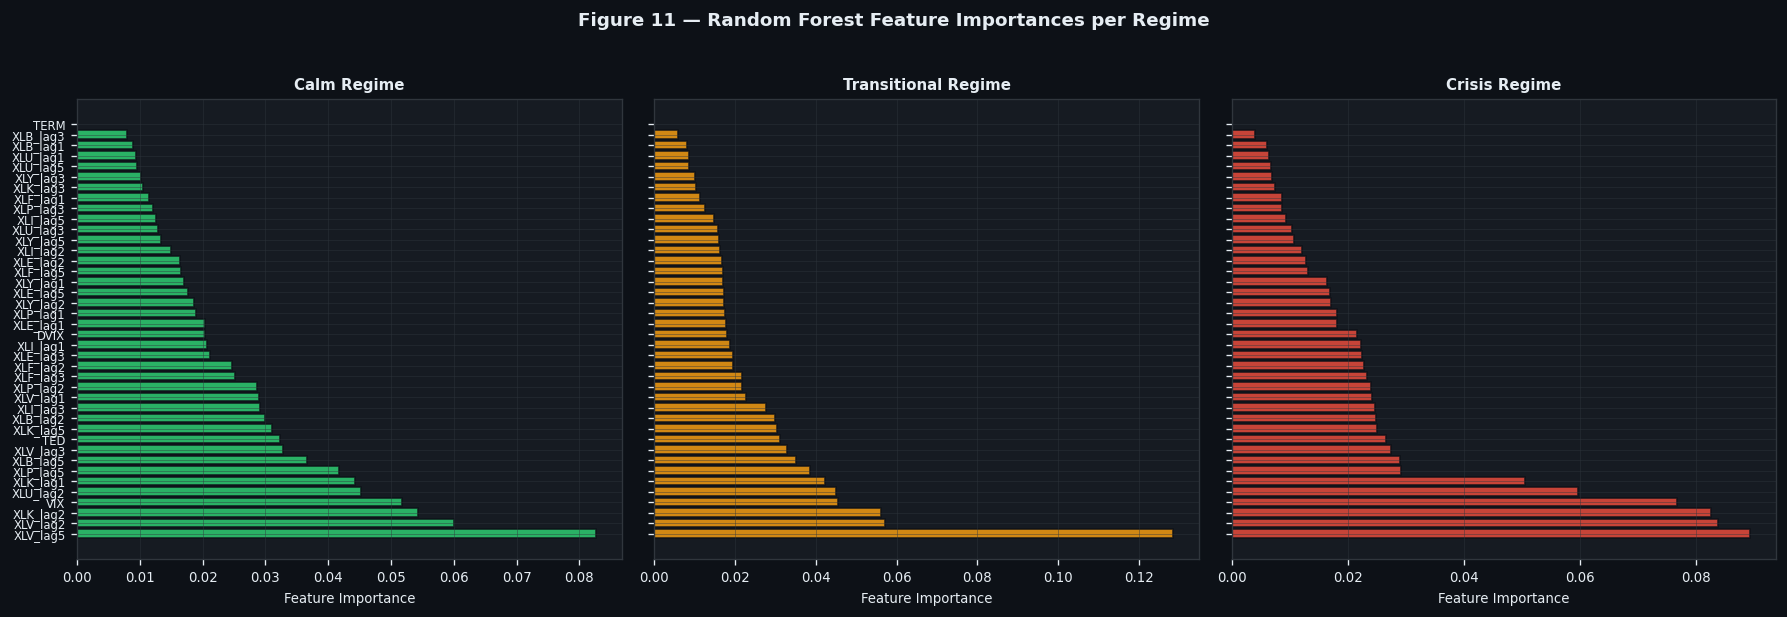

  💾 Saved: 11_feature_importances.png


In [25]:
if ml_last_pipeline and hasattr(ml_last_pipeline, "ensemble_") and ml_last_pipeline.ensemble_:
    feat_imp = ml_last_pipeline.ensemble_.feature_importances()
    vp.plot_feature_importances(feat_imp, rf_feature_names, RESULTS_ABS)
else:
    print("Feature importances not available (pipeline did not run in ensemble mode).")

---
## ✅ Summary

All outputs have been saved to `market_regimes/results/`:

```
results/
├── performance_summary.csv
├── regime_stats.csv
├── beta_summary.csv
├── 01_regime_timeline.png
├── 02_regime_comparison_heatmap.png
├── 03_transition_matrix.png
├── 04_return_distributions.png
├── 05_capm_betas.png
├── 06_portfolio_weights.png
├── 07_cumulative_wealth.png
├── 08_performance_table.png
├── 09_drawdown_profiles.png
├── 10_breakeven_costs.png
└── 11_feature_importances.png
```